# 04 — Coupled power-thermal-cyber SDE simulation

Integrates eq. (11) of the paper with Euler-Maruyama and overlays the resulting **Cox-process intensity** so the link between the latent state $(V_t, T_t, C_t)$ and claim frequency is visible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dcrisk.sde.ptcyber import PTCyberParams, simulate_ptcyber
from dcrisk.frequency.nb_gamma import Cox_intensity

rng = np.random.default_rng(2026)
params = PTCyberParams()
T_max = 24.0 * 7  # 1 week
t, X = simulate_ptcyber(T_max, dt=1/12, n_paths=3, params=params, rng=rng)
lam_t = Cox_intensity(t, X)  # shape (n_paths, N+1)

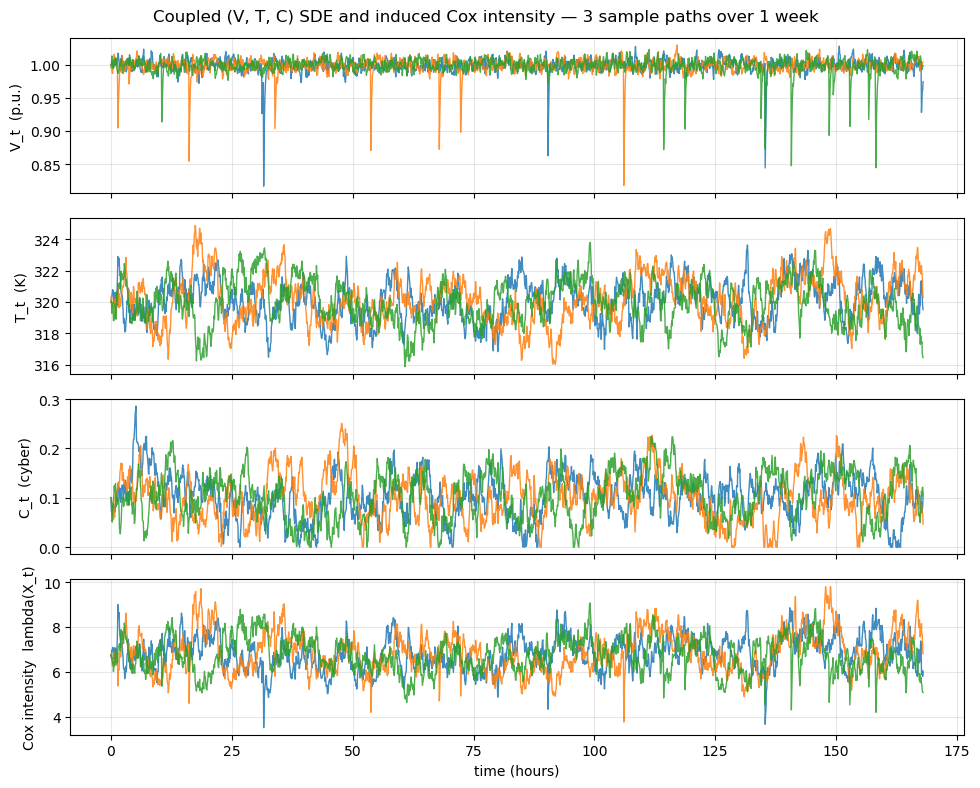

In [2]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for k in range(X.shape[0]):
    axes[0].plot(t, X[k, :, 0], lw=1.0, alpha=0.85)
    axes[1].plot(t, X[k, :, 1], lw=1.0, alpha=0.85)
    axes[2].plot(t, X[k, :, 2], lw=1.0, alpha=0.85)
    axes[3].plot(t, lam_t[k], lw=1.0, alpha=0.85)
axes[0].set_ylabel('V_t  (p.u.)')
axes[1].set_ylabel('T_t  (K)')
axes[2].set_ylabel('C_t  (cyber)')
axes[3].set_ylabel('Cox intensity  lambda(X_t)')
axes[3].set_xlabel('time (hours)')
for a in axes: a.grid(alpha=0.3)
fig.suptitle('Coupled (V, T, C) SDE and induced Cox intensity — 3 sample paths over 1 week')
fig.tight_layout()